In [6]:
# Om något bibliotek saknas:
# !pip install pandas numpy matplotlib tqdm openpyxl

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

pd.set_option("display.max_columns", None)
pd.options.mode.chained_assignment = None

# ============================================================
# FILVÄGAR OCH BLADNAMN
# ============================================================

send_file = r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\send-station-V1.xlsx"
rec_file  = r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\rec-station-V1.xlsx"

keyS_sheet  = "K-nyckel"
dataS_sheet = "Station_K_3x15000"

keyR_sheet  = "F-nyckel"
dataR_sheet = "Station_F_3x15000"

print("send finns:", os.path.exists(send_file))
print("rec finns :", os.path.exists(rec_file))

# ============================================================
# HJÄLPFUNKTIONER
# ============================================================

def read_key_table_safe(filename, sheetname):
    T = pd.read_excel(filename, sheet_name=sheetname, header=None)
    T = T.iloc[:, :2].copy()
    T.columns = ["Parameter", "ID"]
    T = T.dropna()
    return T

def ls_diagnostics(A, Y, beta):
    Y_hat = A @ beta
    resid = Y - Y_hat

    n = len(Y)
    p = A.shape[1]
    dof = max(n - p, 1)

    sigma2 = np.sum(resid**2) / dof
    ATA_inv = np.linalg.pinv(A.T @ A)
    cov_beta = sigma2 * ATA_inv
    se_beta = np.sqrt(np.diag(cov_beta))

    return {
        "residuals_vector": resid,
        "sigma2": sigma2,
        "cov_beta": cov_beta,
        "se_beta": se_beta,
        "dof": dof
    }

def estimate_B_and_K1(vs, vr, is_, ir):
    """
    Eq. (19):
        I^S - K1 I^R = (B/2)(V^S + V^R)
    Okända:
        Re(K1), Im(K1), B
    """
    Y = np.concatenate([np.real(is_), np.imag(is_)])

    ir_re = np.real(ir)
    ir_im = np.imag(ir)

    v_sum = vs + vr
    v_re = np.real(v_sum)
    v_im = np.imag(v_sum)

    A_top = np.column_stack([
        ir_re,
        -ir_im,
        0.5 * v_re
    ])

    A_bot = np.column_stack([
        ir_im,
        ir_re,
        0.5 * v_im
    ])

    A = np.vstack([A_top, A_bot])

    beta, residuals, rank, s = np.linalg.lstsq(A, Y, rcond=None)
    diag = ls_diagnostics(A, Y, beta)

    a, b, B = beta
    K1 = a + 1j * b

    return {
        "K1": K1,
        "B": B,
        "beta": beta,
        "rank": rank,
        "singular_values": s,
        "A": A,
        "Y": Y,
        "cov_beta": diag["cov_beta"],
        "se_beta": diag["se_beta"],
        "sigma2": diag["sigma2"]
    }

def estimate_Z_and_K4(vs, vr, ir, B_est):
    """
    Baseline steg 2:
        V^S - K4 V^R = Z * ( I^R + (jB/2)V^R )
    där Z = R + jX
    Okända:
        Re(K4), Im(K4), R, X
    """
    Ieq = ir + 1j * (B_est / 2.0) * vr
    Y = np.concatenate([np.real(vs), np.imag(vs)])

    vr_re = np.real(vr)
    vr_im = np.imag(vr)

    ieq_re = np.real(Ieq)
    ieq_im = np.imag(Ieq)

    A_top = np.column_stack([
        vr_re,
        -vr_im,
        ieq_re,
        -ieq_im
    ])

    A_bot = np.column_stack([
        vr_im,
        vr_re,
        ieq_im,
        ieq_re
    ])

    A = np.vstack([A_top, A_bot])

    beta, residuals, rank, s = np.linalg.lstsq(A, Y, rcond=None)
    diag = ls_diagnostics(A, Y, beta)

    c, d, R, X = beta
    K4 = c + 1j * d

    return {
        "K4": K4,
        "R": R,
        "X": X,
        "Ieq": Ieq,
        "beta": beta,
        "rank": rank,
        "singular_values": s,
        "A": A,
        "Y": Y,
        "cov_beta": diag["cov_beta"],
        "se_beta": diag["se_beta"],
        "sigma2": diag["sigma2"]
    }

def estimate_Z_and_K4_fixed_X(vs, vr, ir, B_est, X_anchor):
    """
    Modifierat steg 2 med fixerat X = X_anchor.

    Utgår från:
        V^S - K4 V^R = (R + jX0) * Ieq

    där:
        Ieq = I^R + (jB/2)V^R

    Okända:
        Re(K4), Im(K4), R
    """
    Ieq = ir + 1j * (B_est / 2.0) * vr

    vr_re = np.real(vr)
    vr_im = np.imag(vr)

    ieq_re = np.real(Ieq)
    ieq_im = np.imag(Ieq)

    # Flytta de kända X0-termerna till vänsterledet
    Y_top = np.real(vs) + X_anchor * ieq_im
    Y_bot = np.imag(vs) - X_anchor * ieq_re
    Y = np.concatenate([Y_top, Y_bot])

    # Okända: c, d, R
    A_top = np.column_stack([
        vr_re,
        -vr_im,
        ieq_re
    ])

    A_bot = np.column_stack([
        vr_im,
        vr_re,
        ieq_im
    ])

    A = np.vstack([A_top, A_bot])

    beta, residuals, rank, s = np.linalg.lstsq(A, Y, rcond=None)
    diag = ls_diagnostics(A, Y, beta)

    c, d, R = beta
    K4 = c + 1j * d

    return {
        "K4": K4,
        "R": R,
        "X_fixed": X_anchor,
        "Ieq": Ieq,
        "beta": beta,
        "rank": rank,
        "singular_values": s,
        "A": A,
        "Y": Y,
        "cov_beta": diag["cov_beta"],
        "se_beta": diag["se_beta"],
        "sigma2": diag["sigma2"]
    }


send finns: True
rec finns : True


In [7]:
# ============================================================
# LÄS NYCKLAR OCH RÅDATA
# ============================================================

keyS = read_key_table_safe(send_file, keyS_sheet)
keyR = read_key_table_safe(rec_file, keyR_sheet)

send = pd.read_excel(send_file, sheet_name=dataS_sheet, header=None)
rec  = pd.read_excel(rec_file,  sheet_name=dataR_sheet, header=None)

send = send.iloc[:, :3].copy()
rec  = rec.iloc[:, :3].copy()

send.columns = ["Timestamp", "ID", "Value"]
rec.columns  = ["Timestamp", "ID", "Value"]

send["Timestamp"] = pd.to_datetime(
    send["Timestamp"],
    format="%Y-%m-%d %H:%M:%S.%f",
    errors="coerce"
)

rec["Timestamp"] = pd.to_datetime(
    rec["Timestamp"],
    format="%Y-%m-%d %H:%M:%S.%f",
    errors="coerce"
)

send = send.dropna(subset=["Timestamp"])
rec  = rec.dropna(subset=["Timestamp"])

print("send tidsintervall:", send["Timestamp"].min(), "->", send["Timestamp"].max())
print("rec  tidsintervall:", rec["Timestamp"].min(), "->", rec["Timestamp"].max())
print("unika timestamps send:", send["Timestamp"].nunique())
print("unika timestamps rec :", rec["Timestamp"].nunique())

# ============================================================
# MAPPA ID TILL PARAMETER, PIVOTERA OCH SYNKA
# ============================================================

send = send.merge(keyS, on="ID", how="inner")
rec  = rec.merge(keyR, on="ID", how="inner")

wideS = send.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")
wideR = rec.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")

wideS = wideS.add_suffix("_S")
wideR = wideR.add_suffix("_R")

df = wideS.join(wideR, how="inner").sort_index().copy()

print("Antal rader wideS:", len(wideS))
print("Antal rader wideR:", len(wideR))
print("Gemensamma timestamps efter join:", len(df))

# ============================================================
# RENSNING
# ============================================================

required_cols = [
    "UL1MAG_S","UL1ANG_S","UL1MAG_R","UL1ANG_R",
    "IL1MAG_S","IL1ANG_S","IL1MAG_R","IL1ANG_R",
    "UL2MAG_S","UL2ANG_S","UL2MAG_R","UL2ANG_R",
    "IL2MAG_S","IL2ANG_S","IL2MAG_R","IL2ANG_R",
    "UL3MAG_S","UL3ANG_S","UL3MAG_R","UL3ANG_R",
    "IL3MAG_S","IL3ANG_S","IL3MAG_R","IL3ANG_R",
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Saknade kolumner: {missing}")

for c in required_cols:
    df[c] = (
        df[c]
        .astype(str)
        .str.strip()
        .str.replace(",", ".", regex=False)
    )
    df[c] = pd.to_numeric(df[c], errors="coerce")

df_clean = df.dropna(subset=required_cols).copy()

print("Rader efter rensning:", len(df_clean))
print("Start:", df_clean.index.min())
print("Slut :", df_clean.index.max())
print("Tidslängd:", df_clean.index.max() - df_clean.index.min())

# ============================================================
# BYGG FASORER - MED INVERTERAD MOTTAGARSTRÖM
# ============================================================

phasors = {}

for ph in ["L1", "L2", "L3"]:
    Vs = df_clean[f"U{ph}MAG_S"] * np.exp(1j * np.deg2rad(df_clean[f"U{ph}ANG_S"]))
    Vr = df_clean[f"U{ph}MAG_R"] * np.exp(1j * np.deg2rad(df_clean[f"U{ph}ANG_R"]))
    Is = df_clean[f"I{ph}MAG_S"] * np.exp(1j * np.deg2rad(df_clean[f"I{ph}ANG_S"]))
    Ir = -df_clean[f"I{ph}MAG_R"] * np.exp(1j * np.deg2rad(df_clean[f"I{ph}ANG_R"]))  # inverterad

    phasors[ph] = {
        "Vs": Vs,
        "Vr": Vr,
        "Is": Is,
        "Ir": Ir,
    }

print("Fasorer skapade för:", list(phasors.keys()))
print("Mottagarström Ir har inverterats.")


send tidsintervall: 2025-12-11 15:25:02.469999 -> 2025-12-11 15:27:32.459999
rec  tidsintervall: 2025-12-11 15:25:02.469999 -> 2025-12-11 15:27:32.459999
unika timestamps send: 15000
unika timestamps rec : 15000
Antal rader wideS: 15000
Antal rader wideR: 15000
Gemensamma timestamps efter join: 15000
Rader efter rensning: 15000
Start: 2025-12-11 15:25:02.469999
Slut : 2025-12-11 15:27:32.459999
Tidslängd: 0 days 00:02:29.990000
Fasorer skapade för: ['L1', 'L2', 'L3']
Mottagarström Ir har inverterats.


In [8]:
# ============================================================
# FÖNSTERINSTÄLLNINGAR
# ============================================================

dt = df_clean.index.to_series().diff().dropna().dt.total_seconds()

print(dt.describe())
print("\nVanligaste tidssteg:")
print(dt.value_counts().head(10))

fs = 1.0 / dt.median()
print(f"\nUppskattad samplingsfrekvens fs = {fs:.3f} Hz")

window_seconds = 30
step_seconds = 5

WINDOW = int(round(window_seconds * fs))
STEP   = int(round(step_seconds * fs))

R_ref = 1.98
alpha = 0.00403

N = len(df_clean)

print("N =", N)
print("WINDOW =", WINDOW)
print("STEP =", STEP)

if N <= WINDOW:
    raise ValueError(f"För få datapunkter. N={N}, WINDOW={WINDOW}")

idx = np.arange(0, N - WINDOW + 1, STEP)

print("Antal glidfönster =", len(idx))

# ============================================================
# KÖR BASELINE EN GÅNG FÖR ATT FÅ X-ANKARE
# ============================================================

baseline_rows = []

for ph in ["L1", "L2", "L3"]:
    Vs = phasors[ph]["Vs"]
    Vr = phasors[ph]["Vr"]
    Is = phasors[ph]["Is"]
    Ir = phasors[ph]["Ir"]

    for i in tqdm(idx, desc=f"Baseline {ph}"):
        i0 = i
        i1 = i + WINDOW

        vs_w = Vs.iloc[i0:i1].to_numpy()
        vr_w = Vr.iloc[i0:i1].to_numpy()
        is_w = Is.iloc[i0:i1].to_numpy()
        ir_w = Ir.iloc[i0:i1].to_numpy()

        res1 = estimate_B_and_K1(vs_w, vr_w, is_w, ir_w)
        res2 = estimate_Z_and_K4(vs_w, vr_w, ir_w, res1["B"])

        center_ts = df_clean.index[i0 + WINDOW // 2]

        baseline_rows.append({
            "Timestamp": center_ts,
            "Phase": ph,
            "B_S": res1["B"],
            "K1": res1["K1"],
            "K4": res2["K4"],
            "R_Ohm": res2["R"],
            "X_Ohm": res2["X"]
        })

baseline_long = pd.DataFrame(baseline_rows)

baseline_wide = baseline_long.pivot(index="Timestamp", columns="Phase", values=["R_Ohm", "X_Ohm"])
baseline_wide.columns = [f"{a}_{b}" for a, b in baseline_wide.columns]
baseline_wide = baseline_wide.reset_index().sort_values("Timestamp")

# Ta bort första outlier-fönstret även här
baseline_filtered = baseline_wide.iloc[1:].copy()

print("HEAD baseline_filtered:")
display(baseline_filtered.head())

# ============================================================
# BERÄKNA X-ANKARE SOM MEDIAN PER FAS
# ============================================================

X_anchors = {
    "L1": baseline_filtered["X_Ohm_L1"].median(),
    "L2": baseline_filtered["X_Ohm_L2"].median(),
    "L3": baseline_filtered["X_Ohm_L3"].median(),
}

print("Valda X-ankare (median från baseline):")
for ph, x0 in X_anchors.items():
    print(f"{ph}: X0 = {x0:.6f} Ohm")


count    1.499900e+04
mean     1.000000e-02
std      6.012611e-07
min      9.998000e-03
25%      1.000000e-02
50%      1.000000e-02
75%      1.000000e-02
max      1.000200e-02
Name: Timestamp, dtype: float64

Vanligaste tidssteg:
Timestamp
0.010000    9859
0.009999    2531
0.010001    2515
0.010002      51
0.009998      43
Name: count, dtype: int64

Uppskattad samplingsfrekvens fs = 100.000 Hz
N = 15000
WINDOW = 3000
STEP = 500
Antal glidfönster = 25


Baseline L1:   0%|          | 0/25 [00:00<?, ?it/s]

Baseline L2:   0%|          | 0/25 [00:00<?, ?it/s]

Baseline L3:   0%|          | 0/25 [00:00<?, ?it/s]

HEAD baseline_filtered:


,Timestamp,R_Ohm_L1,R_Ohm_L2,R_Ohm_L3,X_Ohm_L1,X_Ohm_L2,X_Ohm_L3
1,2025-12-11 15:25:22.469999,2.107598,1.584150,1.016389,7.148231,6.659383,7.036113
2,2025-12-11 15:25:27.469999,1.980111,1.393762,0.802073,6.489341,6.059509,6.462579
3,2025-12-11 15:25:32.469999,1.952289,1.348792,0.784788,6.579360,6.191410,6.589013
4,2025-12-11 15:25:37.469999,1.919561,1.321480,0.763961,6.492005,6.099745,6.512592
5,2025-12-11 15:25:42.470000,1.931004,1.314881,0.771813,6.743709,6.351037,6.745059


Valda X-ankare (median från baseline):
L1: X0 = 6.471337 Ohm
L2: X0 = 6.028178 Ohm
L3: X0 = 6.431464 Ohm


In [9]:
# ============================================================
# KÖR MODIFIERAD STEG-2 MED FIXERAT X
# ============================================================

all_phase_results_anchor = []

u_R0_rel = 0.001
u_alpha_rel = 0.001

u_R0 = R_ref * u_R0_rel
u_alpha = alpha * u_alpha_rel

for ph in ["L1", "L2", "L3"]:
    Vs = phasors[ph]["Vs"]
    Vr = phasors[ph]["Vr"]
    Is = phasors[ph]["Is"]
    Ir = phasors[ph]["Ir"]

    X0 = X_anchors[ph]
    phase_rows = []

    for i in tqdm(idx, desc=f"Fixed-X {ph}"):
        i0 = i
        i1 = i + WINDOW

        vs_w = Vs.iloc[i0:i1].to_numpy()
        vr_w = Vr.iloc[i0:i1].to_numpy()
        is_w = Is.iloc[i0:i1].to_numpy()
        ir_w = Ir.iloc[i0:i1].to_numpy()

        try:
            # Steg 1 oförändrat
            res1 = estimate_B_and_K1(vs_w, vr_w, is_w, ir_w)

            # Steg 2 med fixerat X
            res2 = estimate_Z_and_K4_fixed_X(vs_w, vr_w, ir_w, res1["B"], X0)
        except np.linalg.LinAlgError:
            continue

        K1_est = res1["K1"]
        B_est  = res1["B"]

        K4_est = res2["K4"]
        R_est  = res2["R"]
        X_est  = res2["X_fixed"]

        se_R = res2["se_beta"][2]

        T_est = ((R_est / R_ref) - 1.0) / alpha + 20.0

        dT_dR = 1.0 / (alpha * R_ref)
        dT_dR0 = -R_est / (alpha * (R_ref**2))
        dT_dalpha = -((R_est / R_ref) - 1.0) / (alpha**2)

        u_T = np.sqrt(
            (dT_dR * se_R)**2 +
            (dT_dR0 * u_R0)**2 +
            (dT_dalpha * u_alpha)**2
        )

        center_ts = df_clean.index[i0 + WINDOW // 2]

        phase_rows.append({
            "Timestamp": center_ts,
            "Phase": ph,
            "X_anchor_Ohm": X0,
            "K1_real": np.real(K1_est),
            "K1_imag": np.imag(K1_est),
            "K4_real": np.real(K4_est),
            "K4_imag": np.imag(K4_est),
            "B_S": B_est,
            "R_Ohm": R_est,
            "X_Ohm": X_est,
            "u_R_Ohm": se_R,
            "T_C": T_est,
            "u_T_C": u_T,
            "R_low_3sigma": R_est - 3 * se_R,
            "R_high_3sigma": R_est + 3 * se_R,
            "T_low_3sigma": T_est - 3 * u_T,
            "T_high_3sigma": T_est + 3 * u_T,
            "rank_step1": res1["rank"],
            "rank_step2": res2["rank"]
        })

    phase_df = pd.DataFrame(phase_rows)
    all_phase_results_anchor.append(phase_df)

results_long_anchor = pd.concat(all_phase_results_anchor, ignore_index=True)

print("Antal resultat-rader:", len(results_long_anchor))
display(results_long_anchor.head())

# ============================================================
# BRETT FORMAT
# ============================================================

out_anchor = results_long_anchor.pivot(
    index="Timestamp",
    columns="Phase",
    values=[
        "X_anchor_Ohm",
        "K1_real", "K1_imag", "K4_real", "K4_imag",
        "B_S", "R_Ohm", "X_Ohm",
        "u_R_Ohm",
        "T_C", "u_T_C",
        "R_low_3sigma", "R_high_3sigma",
        "T_low_3sigma", "T_high_3sigma"
    ]
)

out_anchor.columns = [f"{var}_{ph}" for var, ph in out_anchor.columns]
out_anchor = out_anchor.reset_index().sort_values("Timestamp")

# även här filtrerar vi bort första fönstret för jämförbarhet
out_anchor_filtered = out_anchor.iloc[1:].copy()

print("HEAD out_anchor_filtered:")
display(out_anchor_filtered.head())

# ============================================================
# SUMMARY
# ============================================================

summary_anchor_rows = []

for ph in ["L1", "L2", "L3"]:
    summary_anchor_rows.append({
        "Phase": ph,
        "X_anchor_Ohm": out_anchor_filtered[f"X_anchor_Ohm_{ph}"].iloc[0],
        "R_mean_Ohm": out_anchor_filtered[f"R_Ohm_{ph}"].mean(),
        "R_std_Ohm": out_anchor_filtered[f"R_Ohm_{ph}"].std(),
        "R_min_Ohm": out_anchor_filtered[f"R_Ohm_{ph}"].min(),
        "R_max_Ohm": out_anchor_filtered[f"R_Ohm_{ph}"].max(),
        "T_mean_C": out_anchor_filtered[f"T_C_{ph}"].mean(),
        "T_std_C": out_anchor_filtered[f"T_C_{ph}"].std(),
        "K1_real_mean": out_anchor_filtered[f"K1_real_{ph}"].mean(),
        "K1_imag_mean": out_anchor_filtered[f"K1_imag_{ph}"].mean(),
        "K4_real_mean": out_anchor_filtered[f"K4_real_{ph}"].mean(),
        "K4_imag_mean": out_anchor_filtered[f"K4_imag_{ph}"].mean(),
    })

summary_anchor_df = pd.DataFrame(summary_anchor_rows)

print("SUMMARY ANCHOR:")
display(summary_anchor_df)


Fixed-X L1:   0%|          | 0/25 [00:00<?, ?it/s]

Fixed-X L2:   0%|          | 0/25 [00:00<?, ?it/s]

Fixed-X L3:   0%|          | 0/25 [00:00<?, ?it/s]

Antal resultat-rader: 75


,Timestamp,Phase,X_anchor_Ohm,K1_real,K1_imag,K4_real,K4_imag,B_S,R_Ohm,X_Ohm,u_R_Ohm,T_C,u_T_C,R_low_3sigma,R_high_3sigma,T_low_3sigma,T_high_3sigma,rank_step1,rank_step2
0,2025-12-11 15:25:17.469999,L1,6.471337,1.001242,0.017070,1.048265,-0.000898,0.000019,-18.276727,6.471337,8.055796,-2518.627892,1009.579929,-42.444115,5.890660,-5547.367679,510.111895,3,3
1,2025-12-11 15:25:22.469999,L1,6.471337,0.999878,0.017149,0.999200,0.000670,0.000023,2.107598,6.471337,0.050665,35.990935,6.355035,1.955602,2.259594,16.925830,55.056040,3,3
2,2025-12-11 15:25:27.469999,L1,6.471337,1.002887,0.017276,0.999488,0.000650,0.000015,1.980111,6.471337,0.042553,20.013912,5.338597,1.852453,2.107769,3.998120,36.029704,3,3
3,2025-12-11 15:25:32.469999,L1,6.471337,1.003973,0.017327,0.999545,0.000677,0.000013,1.952289,6.471337,0.036622,16.527195,4.596142,1.842422,2.062156,2.738769,30.315621,3,3
4,2025-12-11 15:25:37.469999,L1,6.471337,1.005242,0.017319,0.999610,0.000638,0.000010,1.919561,6.471337,0.037209,12.425675,4.669348,1.807934,2.031189,-1.582368,26.433717,3,3


HEAD out_anchor_filtered:


,Timestamp,X_anchor_Ohm_L1,X_anchor_Ohm_L2,X_anchor_Ohm_L3,K1_real_L1,K1_real_L2,K1_real_L3,K1_imag_L1,K1_imag_L2,K1_imag_L3,K4_real_L1,K4_real_L2,K4_real_L3,K4_imag_L1,K4_imag_L2,K4_imag_L3,B_S_L1,B_S_L2,B_S_L3,R_Ohm_L1,R_Ohm_L2,R_Ohm_L3,X_Ohm_L1,X_Ohm_L2,X_Ohm_L3,u_R_Ohm_L1,u_R_Ohm_L2,u_R_Ohm_L3,T_C_L1,T_C_L2,T_C_L3,u_T_C_L1,u_T_C_L2,u_T_C_L3,R_low_3sigma_L1,R_low_3sigma_L2,R_low_3sigma_L3,R_high_3sigma_L1,R_high_3sigma_L2,R_high_3sigma_L3,T_low_3sigma_L1,T_low_3sigma_L2,T_low_3sigma_L3,T_high_3sigma_L1,T_high_3sigma_L2,T_high_3sigma_L3
1,2025-12-11 15:25:22.469999,6.471337,6.028178,6.431464,0.999878,0.990307,0.985814,0.017149,0.014852,0.022098,0.999200,0.998894,0.998885,0.000670,0.000661,0.000876,0.000023,0.000049,0.000062,2.107598,1.584150,1.016389,6.471337,6.028178,6.431464,0.050665,0.049591,0.051057,35.990935,-29.609055,-100.762326,6.355035,6.218215,6.401034,1.955602,1.435377,0.863217,2.259594,1.732922,1.169561,16.925830,-48.263701,-119.965428,55.056040,-10.954409,-81.559225
2,2025-12-11 15:25:27.469999,6.471337,6.028178,6.431464,1.002887,0.995986,0.989045,0.017276,0.015565,0.023105,0.999488,0.999335,0.999373,0.000650,0.000622,0.000810,0.000015,0.000034,0.000053,1.980111,1.393762,0.802073,6.471337,6.028178,6.431464,0.042553,0.042217,0.043537,20.013912,-53.468962,-127.620993,5.338597,5.294200,5.459108,1.852453,1.267109,0.671462,2.107769,1.520414,0.932684,3.998120,-69.351560,-143.998317,36.029704,-37.586363,-111.243669
3,2025-12-11 15:25:32.469999,6.471337,6.028178,6.431464,1.003973,0.999134,0.991109,0.017327,0.016080,0.023879,0.999545,0.999421,0.999396,0.000677,0.000648,0.000836,0.000013,0.000026,0.000048,1.952289,1.348792,0.784788,6.471337,6.028178,6.431464,0.036622,0.036276,0.037267,16.527195,-59.104744,-129.787165,4.596142,4.550035,4.673796,1.842422,1.239964,0.672988,2.062156,1.457620,0.896588,2.738769,-72.754851,-143.808551,30.315621,-45.454638,-115.765778
4,2025-12-11 15:25:37.469999,6.471337,6.028178,6.431464,1.005242,1.000392,0.991838,0.017319,0.016359,0.024293,0.999610,0.999478,0.999438,0.000638,0.000606,0.000790,0.000010,0.000023,0.000045,1.919561,1.321480,0.763961,6.471337,6.028178,6.431464,0.037209,0.037045,0.037532,12.425675,-62.527532,-132.397272,4.669348,4.646216,4.707037,1.807934,1.210346,0.651366,2.031189,1.432614,0.876557,-1.582368,-76.466179,-146.518384,26.433717,-48.588885,-118.276160
5,2025-12-11 15:25:42.470000,6.471337,6.028178,6.431464,1.005723,1.000253,0.992476,0.017366,0.016544,0.024577,0.999581,0.999498,0.999417,0.000678,0.000642,0.000830,0.000008,0.000023,0.000044,1.931004,1.314881,0.771813,6.471337,6.028178,6.431464,0.041379,0.041307,0.041690,13.859637,-63.354531,-131.413266,5.191434,5.180031,5.227852,1.806865,1.190959,0.646742,2.055142,1.438803,0.896884,-1.714664,-78.894623,-147.096822,29.433937,-47.814439,-115.729710


SUMMARY ANCHOR:


,Phase,X_anchor_Ohm,R_mean_Ohm,R_std_Ohm,R_min_Ohm,R_max_Ohm,T_mean_C,T_std_C,K1_real_mean,K1_imag_mean,K4_real_mean,K4_imag_mean
0,L1,6.471337,1.929631,0.125120,1.618272,2.129220,13.687581,15.680414,1.001107,0.016978,0.999634,0.000642
1,L2,6.028178,1.330922,0.149563,0.942146,1.618325,-61.344238,18.743589,0.995185,0.015729,0.999503,0.000614
2,L3,6.431464,0.828419,0.147018,0.482766,1.174197,-124.319303,18.424683,0.985336,0.022328,0.999347,0.000809


JÄMFÖRELSE BASELINE vs FIXED-X:


,Phase,Baseline_R_mean,Anchor_R_mean,Baseline_R_std,Anchor_R_std,Baseline_X_mean,Anchor_X_fixed
0,L1,1.929631,1.929631,0.125120,0.125120,6.455670,6.471337
1,L2,1.330922,1.330922,0.149563,0.149563,6.055355,6.028178
2,L3,0.828419,0.828419,0.147018,0.147018,6.442896,6.431464


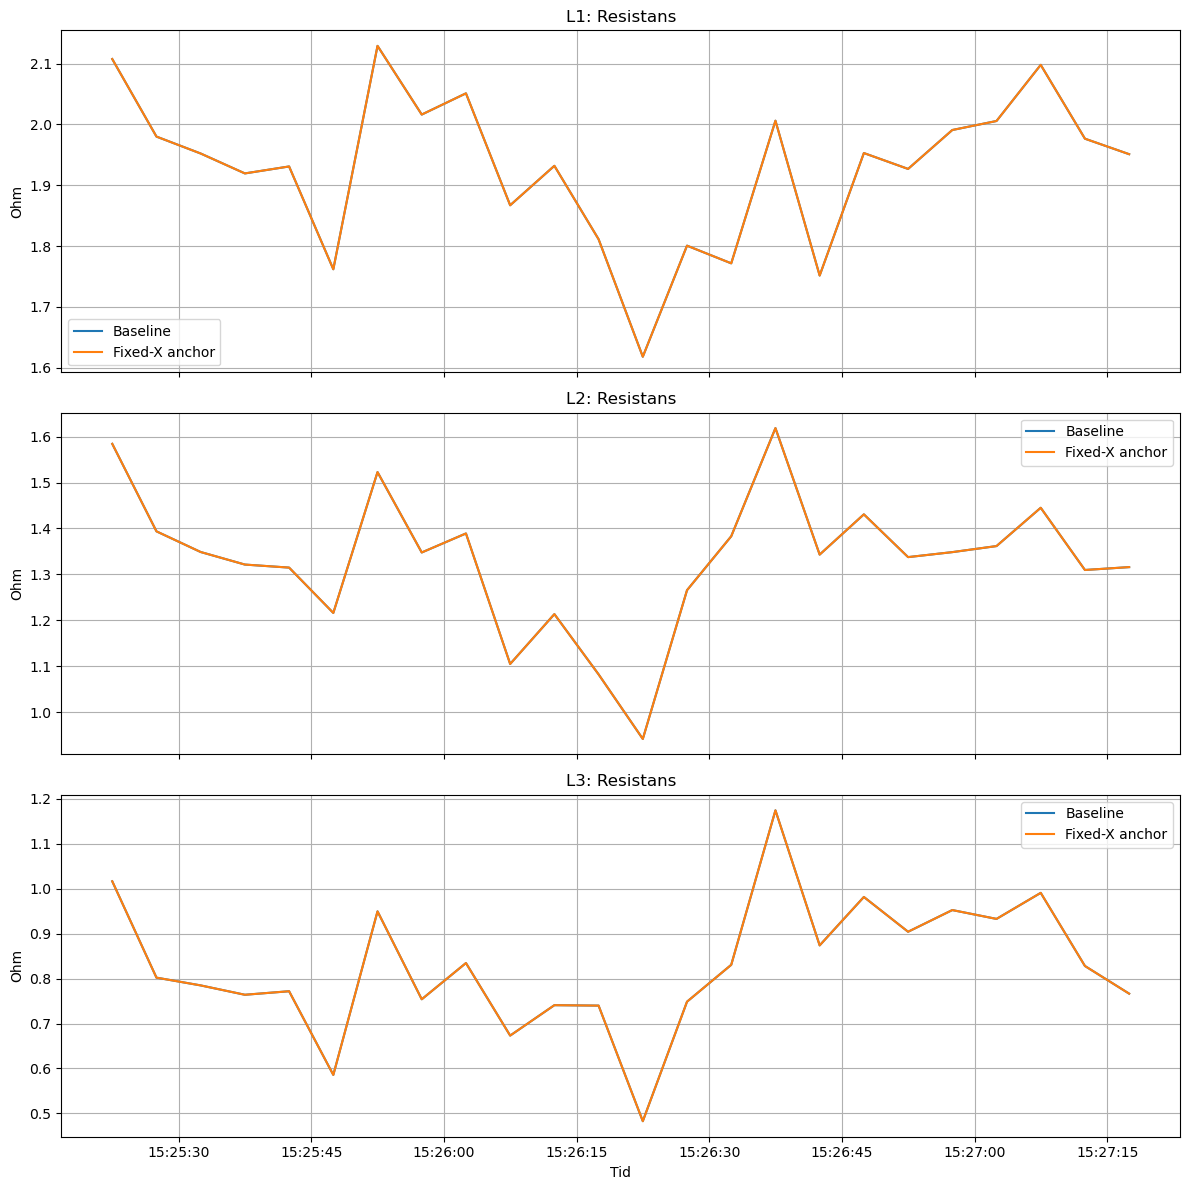

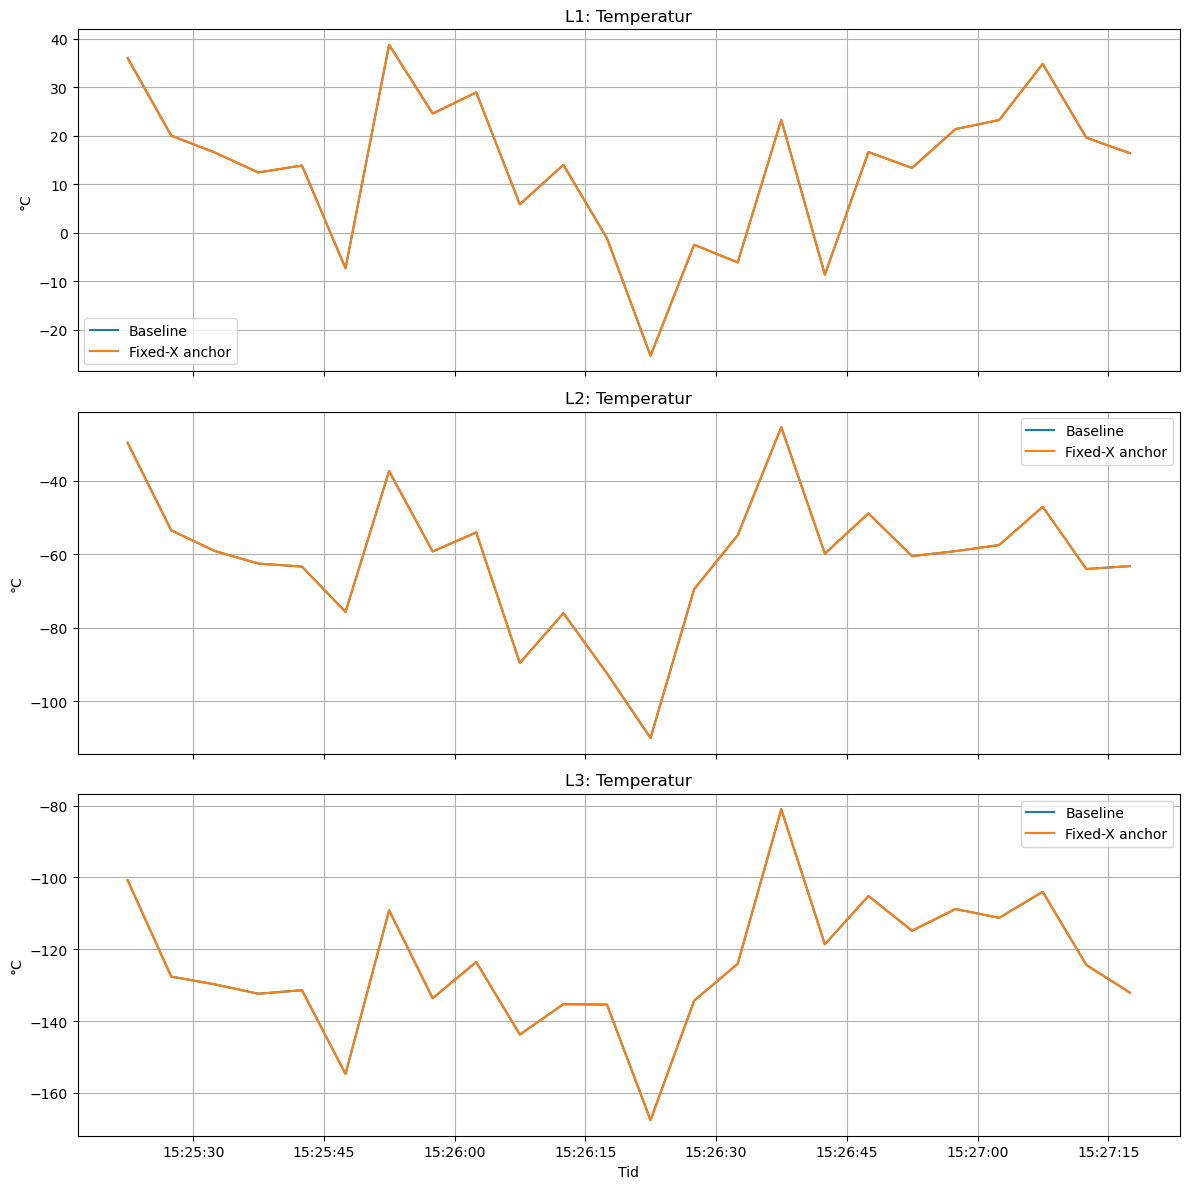

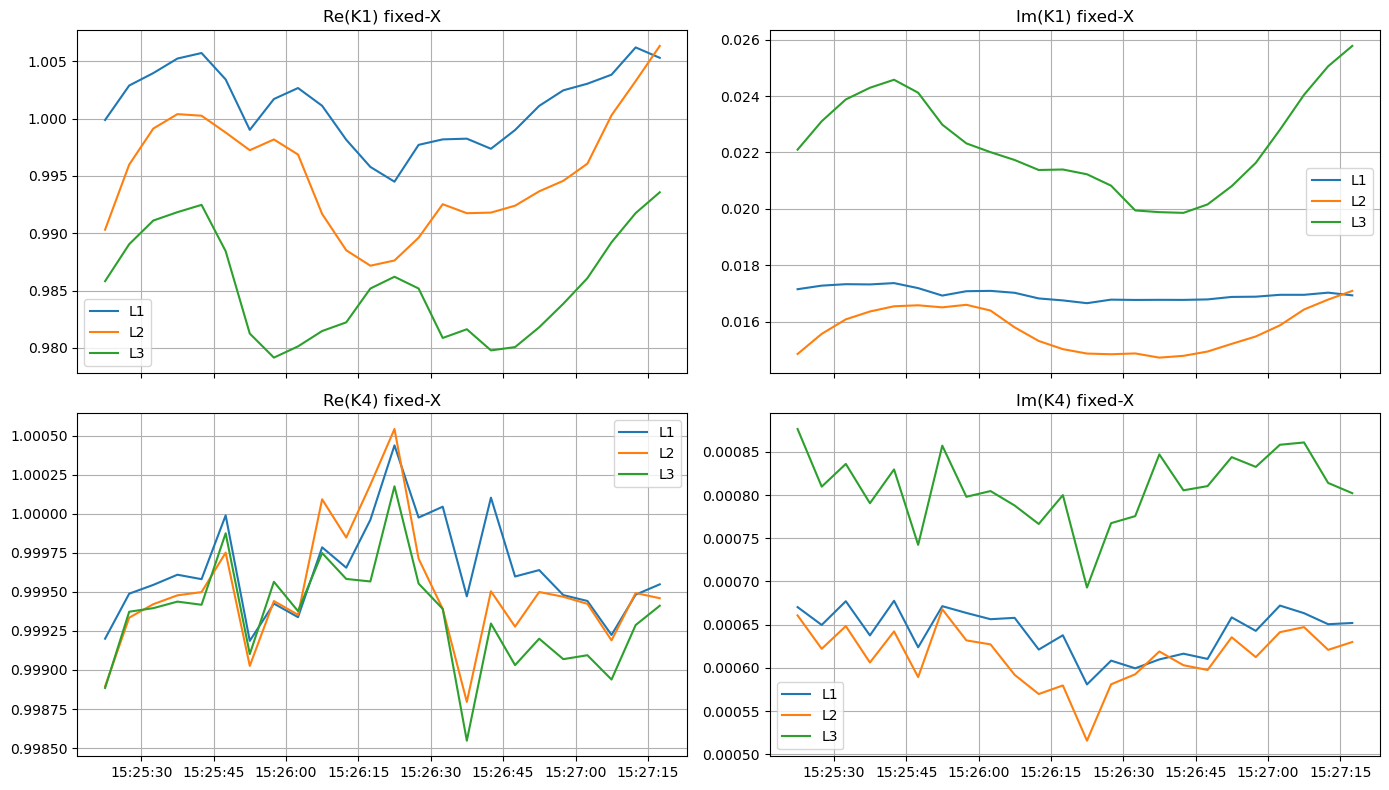

Sparat till: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\singh_fixed_X_anchor.xlsx

HEAD - out_anchor_filtered


,Timestamp,X_anchor_Ohm_L1,X_anchor_Ohm_L2,X_anchor_Ohm_L3,K1_real_L1,K1_real_L2,K1_real_L3,K1_imag_L1,K1_imag_L2,K1_imag_L3,K4_real_L1,K4_real_L2,K4_real_L3,K4_imag_L1,K4_imag_L2,K4_imag_L3,B_S_L1,B_S_L2,B_S_L3,R_Ohm_L1,R_Ohm_L2,R_Ohm_L3,X_Ohm_L1,X_Ohm_L2,X_Ohm_L3,u_R_Ohm_L1,u_R_Ohm_L2,u_R_Ohm_L3,T_C_L1,T_C_L2,T_C_L3,u_T_C_L1,u_T_C_L2,u_T_C_L3,R_low_3sigma_L1,R_low_3sigma_L2,R_low_3sigma_L3,R_high_3sigma_L1,R_high_3sigma_L2,R_high_3sigma_L3,T_low_3sigma_L1,T_low_3sigma_L2,T_low_3sigma_L3,T_high_3sigma_L1,T_high_3sigma_L2,T_high_3sigma_L3
1,2025-12-11 15:25:22.469999,6.471337,6.028178,6.431464,0.999878,0.990307,0.985814,0.017149,0.014852,0.022098,0.999200,0.998894,0.998885,0.000670,0.000661,0.000876,0.000023,0.000049,0.000062,2.107598,1.584150,1.016389,6.471337,6.028178,6.431464,0.050665,0.049591,0.051057,35.990935,-29.609055,-100.762326,6.355035,6.218215,6.401034,1.955602,1.435377,0.863217,2.259594,1.732922,1.169561,16.925830,-48.263701,-119.965428,55.056040,-10.954409,-81.559225
2,2025-12-11 15:25:27.469999,6.471337,6.028178,6.431464,1.002887,0.995986,0.989045,0.017276,0.015565,0.023105,0.999488,0.999335,0.999373,0.000650,0.000622,0.000810,0.000015,0.000034,0.000053,1.980111,1.393762,0.802073,6.471337,6.028178,6.431464,0.042553,0.042217,0.043537,20.013912,-53.468962,-127.620993,5.338597,5.294200,5.459108,1.852453,1.267109,0.671462,2.107769,1.520414,0.932684,3.998120,-69.351560,-143.998317,36.029704,-37.586363,-111.243669
3,2025-12-11 15:25:32.469999,6.471337,6.028178,6.431464,1.003973,0.999134,0.991109,0.017327,0.016080,0.023879,0.999545,0.999421,0.999396,0.000677,0.000648,0.000836,0.000013,0.000026,0.000048,1.952289,1.348792,0.784788,6.471337,6.028178,6.431464,0.036622,0.036276,0.037267,16.527195,-59.104744,-129.787165,4.596142,4.550035,4.673796,1.842422,1.239964,0.672988,2.062156,1.457620,0.896588,2.738769,-72.754851,-143.808551,30.315621,-45.454638,-115.765778
4,2025-12-11 15:25:37.469999,6.471337,6.028178,6.431464,1.005242,1.000392,0.991838,0.017319,0.016359,0.024293,0.999610,0.999478,0.999438,0.000638,0.000606,0.000790,0.000010,0.000023,0.000045,1.919561,1.321480,0.763961,6.471337,6.028178,6.431464,0.037209,0.037045,0.037532,12.425675,-62.527532,-132.397272,4.669348,4.646216,4.707037,1.807934,1.210346,0.651366,2.031189,1.432614,0.876557,-1.582368,-76.466179,-146.518384,26.433717,-48.588885,-118.276160
5,2025-12-11 15:25:42.470000,6.471337,6.028178,6.431464,1.005723,1.000253,0.992476,0.017366,0.016544,0.024577,0.999581,0.999498,0.999417,0.000678,0.000642,0.000830,0.000008,0.000023,0.000044,1.931004,1.314881,0.771813,6.471337,6.028178,6.431464,0.041379,0.041307,0.041690,13.859637,-63.354531,-131.413266,5.191434,5.180031,5.227852,1.806865,1.190959,0.646742,2.055142,1.438803,0.896884,-1.714664,-78.894623,-147.096822,29.433937,-47.814439,-115.729710



TAIL - out_anchor_filtered


,Timestamp,X_anchor_Ohm_L1,X_anchor_Ohm_L2,X_anchor_Ohm_L3,K1_real_L1,K1_real_L2,K1_real_L3,K1_imag_L1,K1_imag_L2,K1_imag_L3,K4_real_L1,K4_real_L2,K4_real_L3,K4_imag_L1,K4_imag_L2,K4_imag_L3,B_S_L1,B_S_L2,B_S_L3,R_Ohm_L1,R_Ohm_L2,R_Ohm_L3,X_Ohm_L1,X_Ohm_L2,X_Ohm_L3,u_R_Ohm_L1,u_R_Ohm_L2,u_R_Ohm_L3,T_C_L1,T_C_L2,T_C_L3,u_T_C_L1,u_T_C_L2,u_T_C_L3,R_low_3sigma_L1,R_low_3sigma_L2,R_low_3sigma_L3,R_high_3sigma_L1,R_high_3sigma_L2,R_high_3sigma_L3,T_low_3sigma_L1,T_low_3sigma_L2,T_low_3sigma_L3,T_high_3sigma_L1,T_high_3sigma_L2,T_high_3sigma_L3
20,2025-12-11 15:26:57.469999,6.471337,6.028178,6.431464,1.002469,0.994574,0.983847,0.016884,0.015473,0.021631,0.999479,0.999469,0.999069,0.000643,0.000613,0.000833,0.000016,0.000037,0.000066,1.990906,1.348527,0.952377,6.471337,6.028178,6.431464,0.026222,0.025433,0.026308,21.366739,-59.137923,-108.784501,3.295657,3.192797,3.301669,1.912240,1.272228,0.873453,2.069571,1.424826,1.031301,11.479767,-68.716315,-118.689508,31.253711,-49.559532,-98.879494
21,2025-12-11 15:27:02.469999,6.471337,6.028178,6.431464,1.003046,0.996071,0.986080,0.016951,0.015867,0.022804,0.999442,0.999423,0.999094,0.000672,0.000641,0.000858,0.000015,0.000033,0.000060,2.005727,1.361713,0.932698,6.471337,6.028178,6.431464,0.026590,0.026165,0.026886,23.224232,-57.485383,-111.250659,3.341767,3.284427,3.373975,1.925958,1.283218,0.852041,2.085497,1.440208,1.013356,13.198930,-67.338663,-121.372583,33.249533,-47.632104,-101.128736
22,2025-12-11 15:27:07.469999,6.471337,6.028178,6.431464,1.003834,1.000293,0.989209,0.016950,0.016429,0.024043,0.999224,0.999190,0.998939,0.000663,0.000647,0.000861,0.000013,0.000022,0.000051,2.097999,1.445029,0.990664,6.471337,6.028178,6.431464,0.031965,0.031916,0.032337,34.788008,-47.044045,-103.986237,4.014604,4.004503,4.056386,2.002104,1.349280,0.893653,2.193895,1.540778,1.087676,22.744197,-59.057554,-116.155395,46.831819,-35.030535,-91.817080
23,2025-12-11 15:27:12.469999,6.471337,6.028178,6.431464,1.006213,1.003273,0.991756,0.017027,0.016782,0.025055,0.999482,0.999493,0.999288,0.000651,0.000621,0.000814,0.000007,0.000015,0.000045,1.976655,1.309684,0.827953,6.471337,6.028178,6.431464,0.034798,0.034737,0.035241,19.580819,-64.005764,-124.377587,4.368063,4.357255,4.420037,1.872260,1.205473,0.722231,2.081050,1.413896,0.933676,6.476629,-77.077530,-137.637697,32.685008,-50.933998,-111.117477
24,2025-12-11 15:27:17.469999,6.471337,6.028178,6.431464,1.005306,1.006344,0.993575,0.016932,0.017089,0.025777,0.999548,0.999459,0.999411,0.000652,0.000630,0.000802,0.000009,0.000008,0.000040,1.951170,1.315945,0.766432,6.471337,6.028178,6.431464,0.044267,0.044049,0.044974,16.386962,-63.221129,-132.087630,5.553067,5.523402,5.639155,1.818369,1.183799,0.631509,2.083972,1.448092,0.901354,-0.272239,-79.791334,-149.005094,33.046163,-46.650924,-115.170165


In [10]:
# ============================================================
# JÄMFÖRELSE BASELINE vs FIXED-X
# ============================================================

comparison_anchor_rows = []

for ph in ["L1", "L2", "L3"]:
    comparison_anchor_rows.append({
        "Phase": ph,
        "Baseline_R_mean": baseline_filtered[f"R_Ohm_{ph}"].mean(),
        "Anchor_R_mean": out_anchor_filtered[f"R_Ohm_{ph}"].mean(),
        "Baseline_R_std": baseline_filtered[f"R_Ohm_{ph}"].std(),
        "Anchor_R_std": out_anchor_filtered[f"R_Ohm_{ph}"].std(),
        "Baseline_X_mean": baseline_filtered[f"X_Ohm_{ph}"].mean(),
        "Anchor_X_fixed": out_anchor_filtered[f"X_Ohm_{ph}"].iloc[0],
    })

comparison_anchor_df = pd.DataFrame(comparison_anchor_rows)

print("JÄMFÖRELSE BASELINE vs FIXED-X:")
display(comparison_anchor_df)

# ============================================================
# PLOTTAR
# ============================================================

# Resistans: baseline vs anchor
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

for ax, ph in zip(axes, ["L1", "L2", "L3"]):
    ax.plot(baseline_filtered["Timestamp"], baseline_filtered[f"R_Ohm_{ph}"], label="Baseline")
    ax.plot(out_anchor_filtered["Timestamp"], out_anchor_filtered[f"R_Ohm_{ph}"], label="Fixed-X anchor")
    ax.set_title(f"{ph}: Resistans")
    ax.set_ylabel("Ohm")
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Tid")
plt.tight_layout()
plt.show()

# Temperatur
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

for ax, ph in zip(axes, ["L1", "L2", "L3"]):
    T_baseline = ((baseline_filtered[f"R_Ohm_{ph}"] / R_ref) - 1.0) / alpha + 20.0
    ax.plot(baseline_filtered["Timestamp"], T_baseline, label="Baseline")
    ax.plot(out_anchor_filtered["Timestamp"], out_anchor_filtered[f"T_C_{ph}"], label="Fixed-X anchor")
    ax.set_title(f"{ph}: Temperatur")
    ax.set_ylabel("°C")
    ax.grid(True)
    ax.legend()

axes[-1].set_xlabel("Tid")
plt.tight_layout()
plt.show()

# K4
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ph in ["L1", "L2", "L3"]:
    axes[0, 0].plot(out_anchor_filtered["Timestamp"], out_anchor_filtered[f"K1_real_{ph}"], label=ph)
    axes[0, 1].plot(out_anchor_filtered["Timestamp"], out_anchor_filtered[f"K1_imag_{ph}"], label=ph)
    axes[1, 0].plot(out_anchor_filtered["Timestamp"], out_anchor_filtered[f"K4_real_{ph}"], label=ph)
    axes[1, 1].plot(out_anchor_filtered["Timestamp"], out_anchor_filtered[f"K4_imag_{ph}"], label=ph)

axes[0, 0].set_title("Re(K1) fixed-X")
axes[0, 1].set_title("Im(K1) fixed-X")
axes[1, 0].set_title("Re(K4) fixed-X")
axes[1, 1].set_title("Im(K4) fixed-X")

for ax in axes.ravel():
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

# ============================================================
# SPARA TILL EXCEL
# ============================================================

output_file = r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\singh_fixed_X_anchor.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:
    baseline_filtered.to_excel(writer, sheet_name="BaselineFiltered", index=False)
    out_anchor_filtered.to_excel(writer, sheet_name="FixedXFiltered", index=False)
    summary_anchor_df.to_excel(writer, sheet_name="FixedXSummary", index=False)
    comparison_anchor_df.to_excel(writer, sheet_name="CompareBaseline", index=False)

print("Sparat till:", output_file)

print("\nHEAD - out_anchor_filtered")
display(out_anchor_filtered.head())

print("\nTAIL - out_anchor_filtered")
display(out_anchor_filtered.tail())
